In [1]:
# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
# TODO: configure PYTHONPATH in devcontainer / environment correctly
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Available Devices : ', dev)
#tf.config.set_visible_devices(dev[0], 'CPU')
#tf.config.set_visible_devices(dev[1], 'GPU')

# Chapter 4: Getting Started with Neural Networks: Classification and Regression

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

The examples from this chapter show some basic end-to-end machine learning workflows.  We introduce data preprocessing,
basic model architecture principles, and model evaluation.

There are examples of classification and regression problems.  Make sure you understand the fundamental difference.
A classification problem is when we try to predict a label.  For example, the simplest classification is binary
classification.  We will predict movie reviews where the class label of the review was either positive or negative,
this is a binary classification problem.  Classification can be more complex.  We have already seen
examples of multiclass classification with the MNIST training set.  In that case, we are trying to predict which of
10 digits each image belongs to.  This is an example of multiclass classification.

A regression problem then is one where we are trying to predict a continuous value.  A good example is predicting house
prices from house features, which we have also seen examples of so far in this class.



# 4.3 Predicting House Prices: A regression example

The two previous datasets we looked at are examples of classification problems, where the goal is to predict
a single discrete label of an input sample.

The other basic kind of machine learning problem is known as a **regression** problem.  When performing a
regression prediction, we are trying to predict a continuous value instead of a discrete categorical
label.  For example, to predict the price of a house in US dollars, as we do in this example, you cannot
think of it as discrete categories, even if you round off to the nearest dollar or thousand of dollars.
You can turn a regression problem into a classification problem, as this example suggests. For example
if you divide house prices into say 10 discrete ranges (under 50k, 50-100k, 100-200k, etc.) then you are
defining categorical labels now and can try and create a classification model.

**Note**: Also don't confuse **regression** problems with **logistic regression** that we have used
and discussed previously in this class.  **Logistic regression** is perhaps unfortunately named, but
it is actually an example of a classification algorithm.

### 4.3.1 The Boston housing price dataset


For the regression example, we will be using the Boston housing dataset, again from the `keras.datasets`
module of example datasets.  The task is to try to predict the median house price of homes in
given regions of the Boston suburbs (in the mid-1970s so the house prices will be much lower than now).

This is quite small dataset, only 506 total samples, split between 404 training samples and 102 test samples.
Also each *feature* in the input data has a different scale.  When input data has different scales or ranges
(for example some features range from 0 to 1, while other range from 0 to 100), this can cause some
problems for certain machine learning regression algorithms, including neural networks.  So we will need
to scale the input tensors so that all features have the same ranges before we train with the data.

Lets load the Boston housing dataset and look at the data.

In [4]:
from tensorflow.keras.datasets import boston_housing
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step


In [5]:
print(train_data.shape)
print(test_data.shape)

(404, 13)
(102, 13)


As we mentioned there are 404 training samples and 102 testing samples.  There are 13 features in this dataset.  The 13 features are
all numerical measurements, such as crime rate, average number of rooms per house, accessibility to highways, etc.

The targets are actually the median value of the houses in a region, in thousands of US dollars.  The median prices of the houses
typically ranged from \$10,000 to \$50,000 in this dataset. 

In [6]:
print(train_targets)

[15.2 42.3 50.  21.1 17.7 18.5 11.3 15.6 15.6 14.4 12.1 17.9 23.1 19.9
 15.7  8.8 50.  22.5 24.1 27.5 10.9 30.8 32.9 24.  18.5 13.3 22.9 34.7
 16.6 17.5 22.3 16.1 14.9 23.1 34.9 25.  13.9 13.1 20.4 20.  15.2 24.7
 22.2 16.7 12.7 15.6 18.4 21.  30.1 15.1 18.7  9.6 31.5 24.8 19.1 22.
 14.5 11.  32.  29.4 20.3 24.4 14.6 19.5 14.1 14.3 15.6 10.5  6.3 19.3
 19.3 13.4 36.4 17.8 13.5 16.5  8.3 14.3 16.  13.4 28.6 43.5 20.2 22.
 23.  20.7 12.5 48.5 14.6 13.4 23.7 50.  21.7 39.8 38.7 22.2 34.9 22.5
 31.1 28.7 46.  41.7 21.  26.6 15.  24.4 13.3 21.2 11.7 21.7 19.4 50.
 22.8 19.7 24.7 36.2 14.2 18.9 18.3 20.6 24.6 18.2  8.7 44.  10.4 13.2
 21.2 37.  30.7 22.9 20.  19.3 31.7 32.  23.1 18.8 10.9 50.  19.6  5.
 14.4 19.8 13.8 19.6 23.9 24.5 25.  19.9 17.2 24.6 13.5 26.6 21.4 11.9
 22.6 19.6  8.5 23.7 23.1 22.4 20.5 23.6 18.4 35.2 23.1 27.9 20.6 23.7
 28.  13.6 27.1 23.6 20.6 18.2 21.7 17.1  8.4 25.3 13.8 22.2 18.4 20.7
 31.6 30.5 20.3  8.8 19.2 19.4 23.1 23.  14.8 48.8 22.6 33.4 21.1 13.6
 32.2 13.1

### 4.3.2 Preparing the data

A neural network, as we mentioned, can have trouble with input features that have wildly different ranges.
So we will need to normalize the input feature ranges for our dataset to get the best performance from
a NN regression model.

The standard best-practice way of dealing with such data is to perform a feature-wise normalization:
each feature in the input data, we subtract the mean of the feature (to center the range around 0) and divide by
the standard deviation of the feature (to normalize it to have a unit standard deviation).

We can easily do this by hand, though again there are also function that do this for you in ML libraries like
`sklearn`.

In [7]:
# center the data by doing feature wise subtraction of the feature mean
mean = train_data.mean(axis=0)
train_data -= mean

# normalize standard deviation of each feature to have a unit (1.0) standard deviation
std = train_data.std(axis=0)
train_data /= std

# normalize the test data, it is subtle here, but notice that we normalize using the
# training data mean and standard deviation
test_data -= mean
test_data /= std

Note that the quantities used for normalizing the test data are the mean and standard deviation of the training data.
You should **NEVER** use any quantity computed on the test data in your
workflow, even for something as simple as data normalization.  Why?  the test data needs to remain
completely unknown to your training workflow.  Even computing feature means of the test data and using them
to clean the data leaks information into the training process.

Just to be clear, the result of normalizing the training data means each feature now has a mean of 0 and a
standard deviation of 1 (so they all have the same range or spread now)

In [8]:
print(train_data.mean(axis=0))
print(train_data.std(axis=0))

[-0.  0.  0. -0. -0.  0.  0.  0.  0. -0.  0.  0.  0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 4.3.3. Building your model

Because so few samples are available, we'll use a very small model with two intermediate layers, each with 64 units.

In general the less training data you have the worse that the problem of overfitting will be for you to create a
truly general and well performing model.  Using a small model (that is not overpowered) is one way to
mitigate overfitting.

Because we need to rebuild the model several times in the following example, we will create a function
to call anytime we need to build and compile a fresh new model.

In [9]:
def build_model():
    """Because we need to instantiate the same model multiple
    times in this example, use a function we can reuse to
    (re)construct it as needed
    """
    model = keras.Sequential([
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

Compare this model to the classification models from the previous 2 examples.  The model ends with a single output
unit, and is not using any activation function on the output.  This is a typical setup for a scalar regression,
where we are trying to predict a single scalar (real valued) number. Activation functions typically restrain
the range of the output (think of the `sigmoid` that coverts the range to 0.0 - 1.0).  We want an unconstrained
output that can (learn) to range from the 7.0 to the 50.0 which is the range of the output regression labels
we are working with for this dataset.

Another difference is that we use the "mse" **Mean Squared Error**  loss function, the square of the difference between the
predictions and the targets.  This is widely used as the loss function for a regression problem.

We are also monitoring the training using the "mae" metric **Mean Absolute Error**.  This is the
absolute value of the error (the L-1 norm as we have called it in a previous assignment).

We will discuss later why we look at this metric.  Also you can use "mae" as a loss function as well for a
regression, though usually "mse" will perform the same or better.

### 4.3.4 Validating your approach using K-fold validation

We could split the data into train and validation sets again, as we did in the previous classification examples. But
our training set is very small here, and we would like to use all of the data we have for training if possible.  Also
for this size of data different random splits of the test and validation can give very different results depending
on which data gets put into the training set and which into the validation set (the validation scores might
have high *variance*, e.g. they can vary a lot depending on the random split).  

The best practice in this situation is to use **K-fold cross-validation**.  In this type of validation during training, we 
randomly split the training data into **K** equal (as much as possible) sized pieces.  We hold one of the K partitions out
for validation and train with the rest.  After training we validate with the held out piece.  But we do this K times
holding out a different piece for the validation each time.  For example if K=5, we would split the data into
5 equal pieces.  We we train the model 5 times, where on each round of training we hold out 1 of the pieces and validate with it.


Again there are methods to handle most of the details of performing a K-fold validation for you in libraries like `sklearn`,
but to illustrate, a simple implementation of K-fold cross-validation by hand is relatively straightforward
to code.

In [10]:
# control the number of folds to perform, here we will use k=4 folds
k = 4
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []


# perform k=4 iterations where we pull out a different piece of the data for
# validation, and use all of the rest to train a model and evaluate its performance
# on the held back validation piece
for i in range(k):
    print(f"Processing fold #{i}")

    # prepares the validation data: data from partition #k
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]

    # prepares the training data: data from all other partitions
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
        train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
        train_targets[(i + 1) * num_val_samples:]],
        axis=0)

    # build the (same) model for each fold/validation
    model = build_model()

    # train the model on the k-1 folds of training data (we use verbose=0, we are
    # evaluating on validation data ourselves)
    model.fit(partial_train_data, partial_train_targets,
        epochs=num_epochs, batch_size=16, verbose=0)

    # evaluate the model on the validation data
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


Running this with `num_epochs = 100` yields the following results (each time you run this will vary but should see similar performance).

In [11]:
print(all_scores)
print(np.mean(all_scores))

[2.1361966133117676, 2.449272632598877, 2.442706823348999, 2.658026695251465]
2.421550691127777


You will see some variation in the "mae" evaluations on the 4 folds.  The average is a much better indication of 
the typical performance we would get with this model than any of the individual runs.

One reason to use the "mae" mean absolute error as our evaluation metric is that we can directly interpret
what it means here.  An average "mae" of 2.3, means that the absolute value of our errors on average was
2.3 thousand dollars.  We could use the "mse" mean squared error, but since these are the squares of the
errors, we would first need to take their square roots (the root mean squared error) to have units that
are similarly interpretable in the original output units.

You may not have a good feel for if a 2.3 thousand dollar prediction error is good or bad here.  Since the
price ranges are in the 10k to 50k range, this does represent a fairly high percentage off in the
predictions.  Lets try training longer, 500 epochs.  Also we will repeat the code here (not something that
is usually a good idea to do) and add in code to keep a record  of how well each model does at each epoch of training, so that
we can visualize the model performance.

In [12]:
# control the number of folds to perform, here we will use k=4 folds
k = 4
num_val_samples = len(train_data) // k
num_epochs = 500
all_histories = [] # we still use a list, but keep a list of the history object returned by keras from the fit

# perform k=4 iterations where we pull out a different piece of the data for
# validation, and use all of the rest to train a model and evaluate its performance
# on the held back validation piece
for i in range(k):
    print(f"Processing fold #{i}")

    # prepares the validation data: data from partition #k
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]

    # prepares the training data: data from all other partitions
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
        train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
        train_targets[(i + 1) * num_val_samples:]],
        axis=0)

    # build the (same) model for each fold/validation
    model = build_model()

    # train the model on the k-1 folds of training data (we use verbose=0, we are
    # evaluating on validation data ourselves)
    history = model.fit(partial_train_data, partial_train_targets,
                        validation_data=(val_data, val_targets),
                        epochs=num_epochs, batch_size=16, verbose=0)

    # we let keras evaluate using the evaluation fold, so we can just keep
    # the validation histories it returns us for each fold of training
    #mae_history = history.history["val_mae"]
    all_histories.append(history)

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


We can then compute the average of the per-epoch MAE validation scores over all 4 folds. And we can visualize
the average MAE per epoch performance.

And while we are at it, I modified the code from the text to append the full history, so lets
extract also the train and validation MSE loss and the train MAE as well into a new
average dictionary so we can reuse our plotting function to see the loss and validation
measures both.

In [13]:
# average the training loss (mse)
d = [h.history['loss'] for h in all_histories]
average_loss = [
    np.mean([x[i] for x in d]) for i in range(num_epochs)
]

# average the validation loss (mse)
d = [h.history['val_loss'] for h in all_histories]
average_val_loss = [
    np.mean([x[i] for x in d]) for i in range(num_epochs)
]

# average the training metric (mae)
d = [h.history['mae'] for h in all_histories]
average_mae = [
    np.mean([x[i] for x in d]) for i in range(num_epochs)
]

# average the validation metric (mae)
d = [h.history['val_mae'] for h in all_histories]
average_val_mae = [
    np.mean([x[i] for x in d]) for i in range(num_epochs)
]

hist_dict = {
    'loss': average_loss,
    'val_loss': average_val_loss,
    'mae': average_mae,
    'val_mae': average_val_mae
}

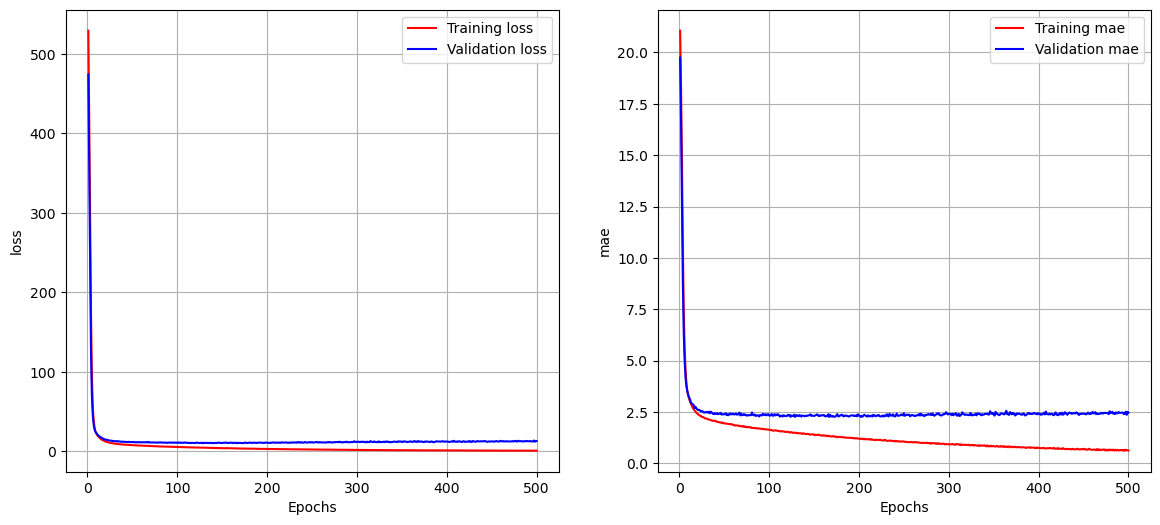

In [14]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, hist_dict, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, hist_dict, 'mae')

There is a little discussion of good visualization in our textbook here.  This plot (the MAE metric on the right in
particular) is a bit difficult to read because of scaling issues.
The "mae" is very high for the first couple of epochs, obscuring the trend a bit of how "mae" changes
past epoch 10 or so.

Let's omit the first 10 data points, which are on a different scale than the rest of the curve.

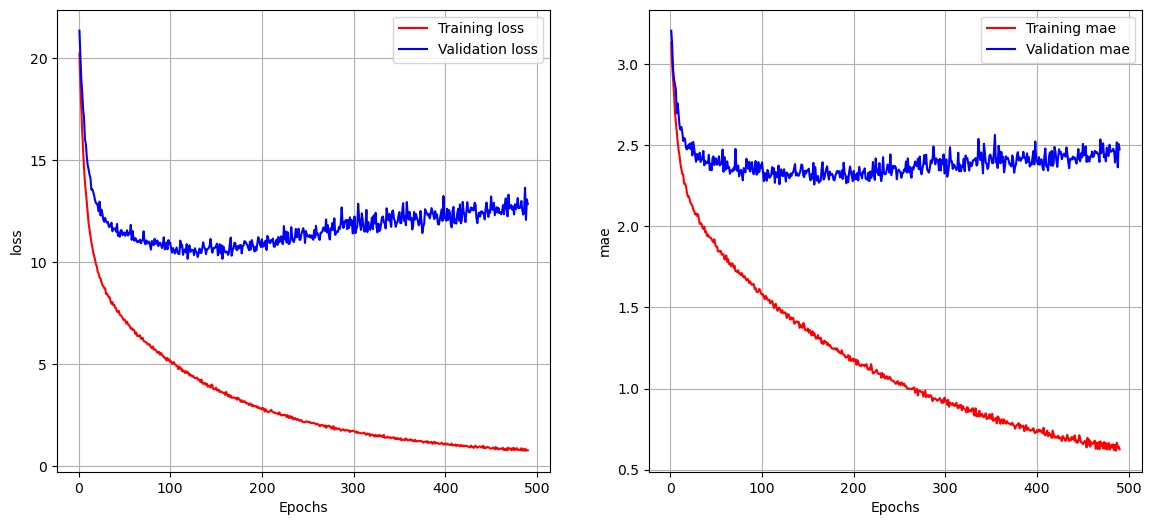

In [15]:
omit_idx = 10
hist_dict = {
    'loss': average_loss[omit_idx:],
    'val_loss': average_val_loss[omit_idx:],
    'mae': average_mae[omit_idx:],
    'val_mae': average_val_mae[omit_idx:]
}

plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, hist_dict, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, hist_dict, 'mae')

The reason the first plot was a bit of a bad visualization is that, there is a clear point where this model
begins overfitting, that is not so easy to see when we include the first few epochs.  Here we can see that
after about 100 epochs or so, the model is showing clear signs of overfitting.  While the loss and our
MAE evaluation metric continue improving on the data we train with, the validation loss and metrics start
to get worse.  This shows that the model is beginning to learn random patterns of noise from the training
data around then.

Once your're finished tuning other parameters of the model (in addition to the number of epochs, you could
also adjust the size of the hidden layers), you can train a final production model on all of the training data, with
the best parameters, than look at its performance on the test data.

This is not an uncommon workflow, and again shows
why validation data or using k-fold cross-validation is needed.  While we need some held back data to evaluate
the performance, the folds in our cross-validation here, we would like here to have a final model using what we
think is the best architecture and parameters, but using all of the training data.  But to be sure we have not
done something stupid or that performance drops drastically, we want a set of data never used in training
or validation to double check final performance.

Here we train a final model, and perform early stopping at epoch 130, as the textbook does, to stop training
where it looks like overfitting is beginning to occur.

In [16]:
# get a fresh model
model = build_model()

# train it on the entirety of the data
model.fit(train_data, train_targets,
          epochs=130, batch_size=16, verbose=False)

# evaluate on the test data
test_mse_score, test_mae_score = model.evaluate(test_data, test_targets)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 17.3508 - mae: 2.5458


Here's the final result on the completely unseen test data

In [17]:
test_mae_score

2.5457630157470703

We're still off by a bit under \$2,500. This is about the same as when we first tried 100 epochs.  We
have only increased the epochs a bit, using evidence of where overfitting is probably beginning
to be an effect.  You should be able to find architecture tweaks that would do better here.

### 4.3.5 Generating prediction on new data

As usual, we can call `predict()` to generate predictions on input data, seen or unseen.  When calling predict on our first
binary classification example, the score was scaled through the `sigmoid()` activation, resulting in an output
in the range from 0 to 1.  With the multiclass classification model, you saw we received a probability distribution
over all classes for each sample.  

With scalar regression we again have a single output unit in the output layer, and since we specified no activation
function on the final output, the values are free to range as needed for the training data.  We can of course
interpret this output as the model's guess for each sample's price in thousands of dollars.

In [18]:
predictions = model.predict(test_data)
print(predictions[:10].flatten())
print(test_targets[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[ 9.7048 19.74   21.5405 35.5359 23.9348 22.5793 27.3475 21.9655 19.618
 22.0694]
[ 7.2 18.8 19.  27.  22.2 24.5 31.2 22.9 20.5 23.2]


### 4.3.6 Wrapping up

<font color='blue'>
    
Here is what you should take away from this scalar regression example:

- Regression is done using different loss function than for classification.  Mean squared error (MSE)
  is the most commonly used for regression.
- Regression models should end with a `Dense` layer with a single output, and no activation function
  so that the output layer can learn an unconstrained output range to match the input training data.
- Similarly evaluation metrics to be used for regression must differ: naturally accuracy is not a concept
  that makes sense.  A common regression metric is mean absolute error (MAE)
- When features in the input data have values in different ranges, each feature should be scaled independently
  as a preprocessing step.
- When there is little data available, using K-fold cross-validation is a great way to reliably evaluate
  a model.
- When little training data is available, use a small model with few intermediate layers in order to avoid
  severe overfitting.

# Chapter 4 Summary

- The three most common kinds of machine learning tasks on vector data are binary classification,
  multiclass classification, and scalar regression
- You'll usually need to preprocess raw data before feeding it into a neural network.
- When your data has features with different ranges, scale each feature independently as part of preprocessing.
- As training progresses, neural networks eventually begin to overfit and obtain worse results on never-before-seen
  data (validation data).
  - Using learning curves of the loss and/or evaluation metrics can be used to spot where overfitting is beginning to occur.
- If you don't have much training data, use a small model with only one or two intermediate layers, to avoid severe overfitting.
- If your data is divided into many categories, you may cause information bottlenecks if you make the intermediate
  layers too small.
- When you're working with little data, K-fold validation can help reliably evaluate your model.